## To Do List
  1. Constructing the exact BW peaks
  2. Constructing the training data - correlators with noise
  3. Preparing the two NN representations
  4. Writing the Training loops
  5. Implementing the two losses with $\rho(\omega)$ the reconstructed spectral function and $\tilde{\rho}(\omega)$ - the ground truth
      - MSE with $\int^{\infty}_0 \left(\tilde{\rho}(\omega) - \rho(\omega) \right)$
      - DKL with $\int^{\infty}_0 \rho(\omega) \log \left( \frac{\rho(\omega)}{\tilde{\rho}(\omega)} \right)$
  7. Re-run the code with different instances of noice for $D(p_i)$ and perform a Jacknife analysis estimating the propagation of errors on $\rho (\omega)$

The BW peaks to be tested are the single and double as used in [this paper](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.106.L051502) , Section IV. Important details on the Training setups and Mock lattice data preparation are given in this [Supplemental paper](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.106.L051502/supplementary_material.pdf)

$\rho^{(BW)}(\omega) = \frac{4 A \Gamma \omega}{\left(M^2 + \Gamma^2 - \omega^2 \right)^2 + 4 \Gamma^2 \omega^2}$, with 
- $A=1.0$, $\Gamma=0.5$, $M=2.0$
- $A_1 = 0.8$, $A_2 = 1.0$,  $\Gamma_1=\Gamma_2=0.5$, $M_1=2.0$, $M_2=5.0$

In [21]:
import numpy as np
from matplotlib import pyplot as plt
# import tensorflow as tf
# import correlator
import physicsHelper
# import lossCalculator

In [22]:
## Constructing the exact BW peaks
##Single peak
A = np.array([1.0])
Ga = np.array([0.5])
M = np.array([2.0])
##Double peak
A = np.array([0.8,1.0])
Ga = np.array([0.5,0.5])
M = np.array([2.0,5.0])
#List of frequencies 
omega = np.linspace(0,19.96,500)
del_omega = omega[1]-omega[0]

In [23]:
##Depending on which list you choose construct and save the spec_func as below and comment them out
#spec1BW = BWfun(A,Ga,M,omega)
spec2BW = physicsHelper.BWfun(A,Ga,M,omega)
spec2BWOverOmega = physicsHelper.BWfunOverOmega(A,Ga,M,omega)

# # plt.plot(omega,spec1BW,label=r'1 BW peak')
# plt.plot(omega,spec2BW, label=r'2 BW peaks')
# #plt.plot(omega,spec3BW, label=r'3 BW peaks')

# plt.legend()
# plt.xlim(0,10)


In [24]:
epsilon = 0 #This epsilon controls momentum close to 0 so that kernel doesnt have zero eigenvalues
x = np.linspace(epsilon,19.2+epsilon,25)
del_xi = x[1]-x[0]

# kl_ker=correlator.KL_kernel_Momentum(x,omega)
# klW_ker=correlator.KL_kernel_Omega(correlator.KL_kernel_Momentum,p,omega)
# kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
# klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)

# ##Again Dpi can represent both 1BW or 2BW depending on whether you pass spec1W or spec2W - Be careful!
# Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)

In the cell below, the main training is taking place - feel free to change the following parameters for the experiment:
- lambda_s
- lambda_l2
- epochs both in warm-up and training loops
- learning rates both in warm-up and training loops
- gauss_width between all ones and the relative error on Dp_i

One can also change the number of hidden layers or the width of each layer but care has to be taken in order not to induce syntax errors 

When you makes changes - you only need to re-run the cell below for re-training. 

# New
Either main_loss becomes a vector corresponding to different target_outputs diff noisy_Dpi
The idea is that yPred should fit many correlator instances 
We do this for each epoch - minimise over different targets. After the epoch loop - put a noisy Dpi loop
   

In [5]:
# Train the model using the inbuilt `fit`-didn't work beacuse input-output dimensions don't match hence had to write a custom training loop
from multiprocessing import Pool


# Create input data and target
 # Constant input node which goes to 500 omegas as the NN structure in paper
# target_output = tf.convert_to_tensor(noisy_dxi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s_warmup = 1.0e-4
lambda_l2_warmup = 1.0e-4
lambda_s = 0#1.0e-5
lambda_l2 = 0#1.0e-9
epochs=1000
new_epochs = 10000

num_samples = 30
gauss_width = np.ones(len(x)) #for mean square error
Dxi_ensemble=[]
noisy_Dxi_ensemble=[]
rho_ensemble=[]
total_loss_history_ensemble=[]
loss_history_ensemble=[]

def func(i):
    import models
    import lossCalculator
    import correlator
    import tensorflow as tf
    constant_input = tf.constant([[1.0]], dtype=tf.float32) #NN
    constant_input = tf.constant(omega, dtype=tf.float32)  #NNP2p
    constant_input = tf.reshape(constant_input, (-1, 1)) #NNP2p
    klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
    kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
    kern=kl_ker_Pos
    Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)
    ep_noise=3e-2
    noisy_dxi_tensor = []
    num_samples = 1
    noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,ep_noise)
    gauss_width=custom_std
    model = models.SpectralNNP2P(num_output_nodes=500, width=128, depth=3)
    target_output = tf.constant(noisy_Dxi, dtype=tf.float32)
    lossCalc=lossCalculator.LossCalculator(model=model,
                                        y_true=target_output,
                                        kernel=kern,
                                        delomega=del_omega,
                                        x=constant_input,
                                        std=gauss_width,
                                        lambda_s_func_warmup=lambda x:lambda_s_warmup,
                                        lambda_s_func=lambda x:lambda_s,
                                        lambda_l2_func_warmup=lambda x:lambda_l2_warmup,
                                        lambda_l2_func=lambda x:lambda_l2
                                            )
    # Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    trainer=models.networkTrainer(model,optimizer,lossCalc)
    total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
    trainer.optimizer=optimizer
    total_loss_history,loss_history=trainer.train(new_epochs,warmup=False,verbose=True)
    rho=model(constant_input)
    return Dxi.numpy(),noisy_Dxi.numpy(),rho.numpy(),total_loss_history,loss_history


pool=Pool(10)
Dxi_ensemble,noisy_Dxi_ensemble,rho_ensemble,total_loss_history_ensemble,loss_history_ensemble=zip(*pool.map(func,range(num_samples)))

# results.wait()

pool.close()
Dxi_ensemble=np.array(Dxi_ensemble)
noisy_Dxi_ensemble=np.array(noisy_Dxi_ensemble)
rho_ensemble=np.array(rho_ensemble)
total_loss_history_ensemble=np.array(total_loss_history_ensemble)
loss_history_ensemble=np.array(loss_history_ensemble)




2024-12-04 11:12:07.670773: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-04 11:12:07.670771: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-04 11:12:07.670773: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-04 11:12:07.670772: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly 

Training for 1000 epochs
Training for 1000 epochs
Training for 1000 epochsTraining for 1000 epochs

Training for 1000 epochs
Training for 1000 epochs
Training for 1000 epochs
Training for 1000 epochs


2024-12-04 11:12:08.566164: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 11:12:08.574152: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 11:12:08.615092: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 11:12:08.616688: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 11:12:08.625935: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 11:12:08.630615: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1

Epoch 0, Loss: 4.375359535217285
Epoch 0, Loss: 10.020450592041016
Epoch 0, Loss: 15.430132865905762
Epoch 0, Loss: 4.583398818969727
Epoch 0, Loss: 2.1792588233947754
Epoch 0, Loss: 9.019484519958496
Epoch 0, Loss: 2.8720896244049072Epoch 0, Loss: 21.034841537475586

Training for 1000 epochs
Training for 1000 epochs
Epoch 0, Loss: 4.016242980957031


2024-12-04 11:12:09.059023: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2024-12-04 11:12:09.097324: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 0, Loss: 21.079978942871094
Epoch 100, Loss: 0.10963539034128189
Epoch 100, Loss: 0.11328565329313278
Epoch 100, Loss: 0.13029682636260986
Epoch 100, Loss: 0.13310851156711578
Epoch 100, Loss: 0.11328169703483582
Epoch 100, Loss: 0.1108502671122551
Epoch 100, Loss: 0.11880315095186234
Epoch 100, Loss: 0.11778853088617325
Epoch 100, Loss: 0.1367679089307785
Epoch 100, Loss: 0.11282801628112793
Epoch 200, Loss: 0.1095518097281456
Epoch 200, Loss: 0.11323710530996323
Epoch 200, Loss: 0.11380746215581894
Epoch 200, Loss: 0.11052247136831284
Epoch 200, Loss: 0.10996036231517792
Epoch 200, Loss: 0.11040674149990082
Epoch 200, Loss: 0.11133265495300293
Epoch 200, Loss: 0.1103435680270195
Epoch 200, Loss: 0.11339769512414932
Epoch 200, Loss: 0.11025998741388321
Epoch 300, Loss: 0.11065654456615448
Epoch 300, Loss: 0.1100495234131813
Epoch 300, Loss: 0.10952278971672058
Epoch 300, Loss: 0.10991832613945007
Epoch 300, Loss: 0.11130568385124207
Epoch 300, Loss: 0.10978133976459503
Epoch 300

2024-12-04 11:16:49.754791: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-04 11:16:49.755566: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-04 11:16:49.758600: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-04 11:16:49.768570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1733307409.785461   16233 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1733307409.79

Training took 262.35439586639404 seconds
Training took 262.9989814758301 seconds
Training took 262.9795048236847 seconds


2024-12-04 11:16:51.689140: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Training took 263.6493308544159 seconds
Training for 1000 epochs


Epoch 0, Loss: 9.421634674072266Epoch 100, Loss: 0.15789958834648132Training for 1000 epochs
Epoch 0, Loss: 9.36544418334961
Training for 1000 epochs

Epoch 0, Loss: 3.9308230876922607Training took 264.28322672843933 seconds
Training took 265.8741714954376 seconds
Training for 1000 epochs
Training took 265.26644921302795 seconds
Epoch 0, Loss: 17.563810348510742
Training for 1000 epochs
Epoch 0, Loss: 4.828808784484863
Epoch 100, Loss: 0.11617446690797806

Epoch 200, Loss: 0.1191081553697586Training for 1000 epochs
Epoch 0, Loss: 9.1251220703125
Epoch 100, Loss: 0.11604953557252884
Epoch 100, Loss: 0.1123037114739418
Training for 1000 epochs

Epoch 0, Loss: 2.326090097427368Training for 1000 epochs
Epoch 0, Loss: 23.224651336669922
Epoch 100, Loss: 0.13272421061992645
Training for 1000 epochs
Epoch 0, Loss: 12.793444633483887
Epoch 200, Loss: 0.11005746573209763
Epoch 300, Loss: 0.1134393960237503
Epoch 100, Loss: 0.113

In [7]:
np.save('data/rho_Ensemble_30_corrs_rhoFit',rho_ensemble)
np.save('data/total_loss_history_Ensemble_30_corrs_rhoFit',total_loss_history_ensemble)
np.save('data/loss_history_Ensemble_30_corrs_rhoFit',loss_history_ensemble)

In [8]:
def bootstrapMean(samples):
    mean=np.mean(samples,axis=0)
    mean=np.squeeze(mean)
    return mean

def bootstrapVariance(samples):
    mean=bootstrapMean(samples)
    variance=np.mean((samples-mean)**2,axis=0)
    return variance

Text(0, 0.5, '$\\rho/\\omega$')

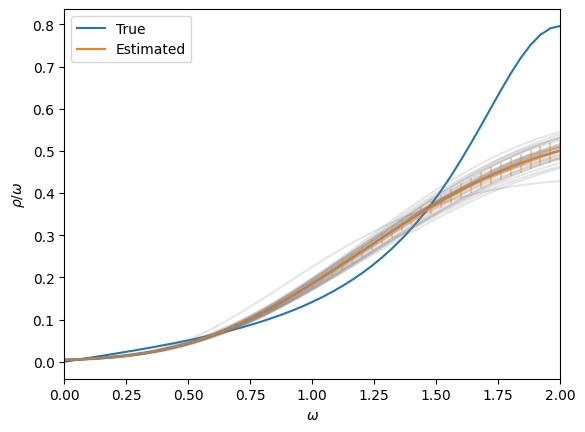

In [30]:
mean=bootstrapMean(np.squeeze(np.array(rho_ensemble)))
variance=bootstrapVariance(np.squeeze(np.array(rho_ensemble)))
plt.plot(omega,spec2BW, label=r'True')
plt.plot(omega,mean, label=r'Estimated',color='C1')
for i in range(num_samples):
    plt.plot(omega,np.squeeze(rho_ensemble[i]),alpha=0.2,color='gray')
plt.errorbar(omega,mean,yerr=np.sqrt(variance),alpha=0.4,color='C1')
plt.legend()
plt.xlim(0,2)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


In [24]:
(np.squeeze(np.array(rho_ensemble))/omega).shape

/tmp/ipykernel_16167/1952122330.py:1: RuntimeWarning: divide by zero encountered in divide
  (np.squeeze(np.array(rho_ensemble))/omega).shape


(30, 500)

/tmp/ipykernel_16167/2218229877.py:1: RuntimeWarning: divide by zero encountered in divide
  mean=bootstrapMean((np.squeeze(np.array(rho_ensemble))/omega))
/tmp/ipykernel_16167/2218229877.py:2: RuntimeWarning: divide by zero encountered in divide
  variance=bootstrapVariance((np.squeeze(np.array(rho_ensemble))/omega))
/tmp/ipykernel_16167/3188300730.py:8: RuntimeWarning: invalid value encountered in subtract
  variance=np.mean((samples-mean)**2,axis=0)
/tmp/ipykernel_16167/2218229877.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')
/tmp/ipykernel_16167/2218229877.py:6: RuntimeWarning: divide by zero encountered in divide
  plt.plot(omega,np.squeeze(rho_ensemble[i])/omega,alpha=0.2,color='gray')


Text(0, 0.5, '$\\rho/\\omega$')

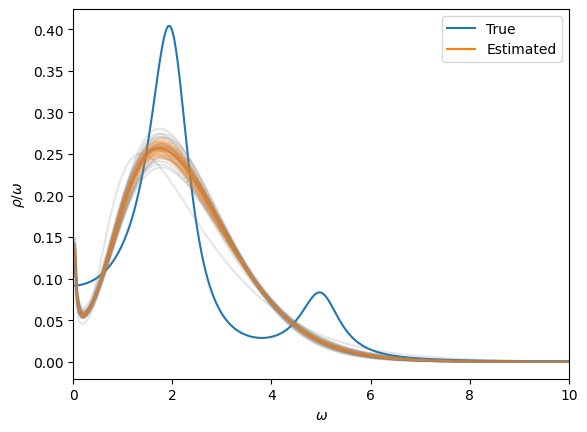

In [29]:
mean=bootstrapMean((np.squeeze(np.array(rho_ensemble))/omega))
variance=bootstrapVariance((np.squeeze(np.array(rho_ensemble))/omega))
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,mean, label=r'Estimated',color='C1')
for i in range(num_samples):
    plt.plot(omega,np.squeeze(rho_ensemble[i])/omega,alpha=0.2,color='gray')
plt.errorbar(omega,mean,yerr=np.sqrt(variance),alpha=0.4,color='C1')
plt.legend()
plt.xlim(0,10)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')

/tmp/ipykernel_88511/958052174.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')


Text(0, 0.5, '$\\rho/\\omega$')

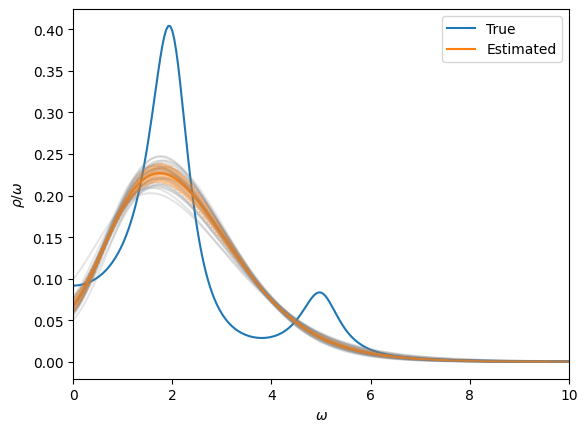

In [17]:
mean=bootstrapMean(np.squeeze(np.array(rho_ensemble)))
variance=bootstrapVariance(np.squeeze(np.array(rho_ensemble)))
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,mean, label=r'Estimated',color='C1')
for i in range(num_samples):
    plt.plot(omega,np.squeeze(rho_ensemble[i]),alpha=0.2,color='gray')
plt.errorbar(omega,mean,yerr=np.sqrt(variance),alpha=0.4,color='C1')
plt.legend()
plt.xlim(0,10)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')

Text(0, 0.5, '$\\rho/\\omega$')

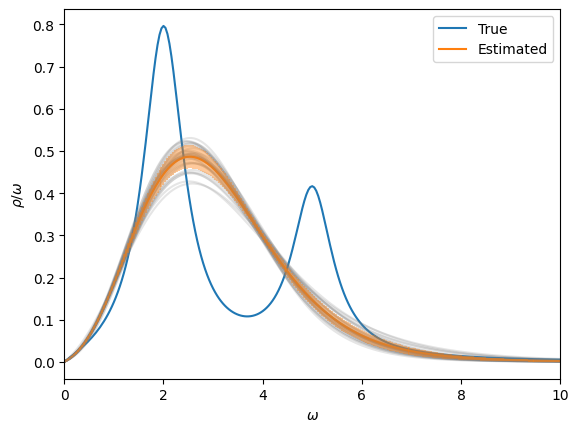

In [16]:
mean=bootstrapMean(np.squeeze(np.array(rho_ensemble)))
variance=bootstrapVariance(np.squeeze(np.array(rho_ensemble)))
plt.plot(omega,spec2BW, label=r'True')
plt.plot(omega,mean*omega, label=r'Estimated',color='C1')
for i in range(num_samples):
    plt.plot(omega,np.squeeze(rho_ensemble[i])*omega,alpha=0.2,color='gray')
plt.errorbar(omega,mean*omega,yerr=np.sqrt(variance)*omega,alpha=0.4,color='C1')
plt.legend()
plt.xlim(0,10)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


/tmp/ipykernel_481984/3183721673.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(omega,spec2BW/omega, label=r'True')


Text(0, 0.5, '$\\rho/\\omega$')

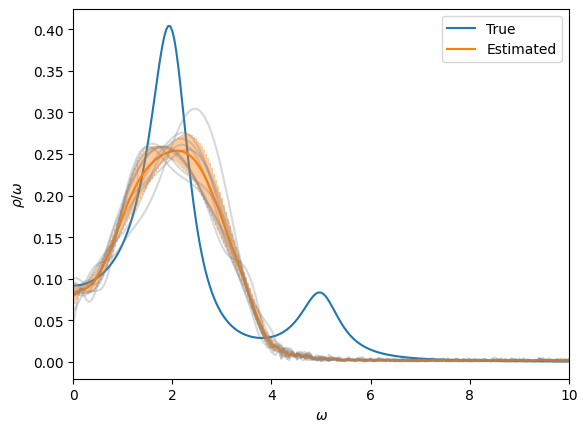

In [23]:
mean=bootstrapMean(np.array(rho_ensemble))
variance=bootstrapVariance(np.array(rho_ensemble))
plt.plot(omega,spec2BW/omega, label=r'True')
plt.plot(omega,mean, label=r'Estimated',color='C1')
plt.errorbar(omega,mean,yerr=np.sqrt(variance),alpha=0.4,color='C1')
for i in range(num_samples):
    plt.plot(omega,np.squeeze(rho_ensemble[i]),alpha=0.3,color='gray')
plt.legend()
plt.xlim(0,10)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


Text(0.5, 0, 'Epochs')

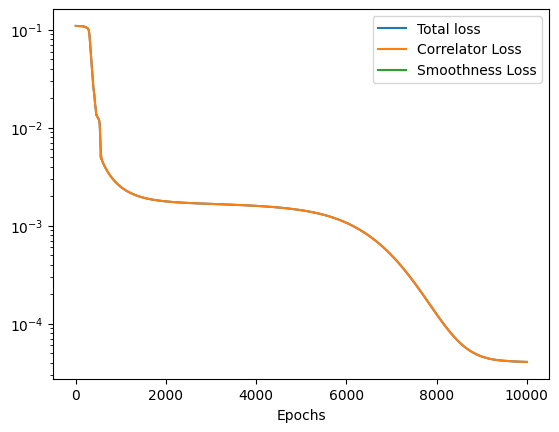

In [31]:
trainingepochs=range(new_epochs)

plt.figure()
plt.plot(trainingepochs,np.mean(total_loss_history_ensemble,axis=0),label=r'Total loss')
plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[0].T,axis=0),label=r'Correlator Loss')
plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[1].T,axis=0)*lambda_s,label=r'Smoothness Loss')
# plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[2].T,axis=0)*0.5*lambda_l2,label=r'L2 Loss')

plt.yscale('log')
plt.legend()
plt.xlabel('Epochs')

Text(0.5, 0, 'Epochs')

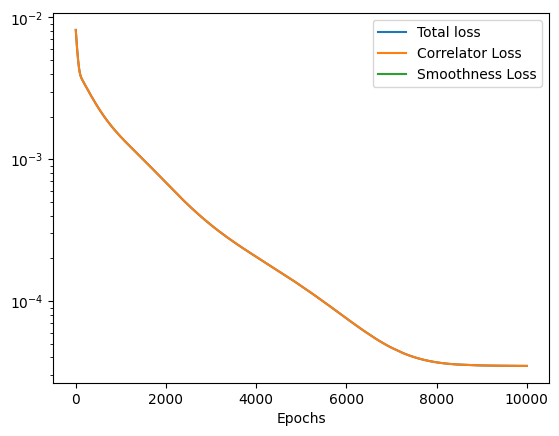

In [8]:
trainingepochs=range(new_epochs)

plt.figure()
plt.plot(trainingepochs,np.mean(total_loss_history_ensemble,axis=0),label=r'Total loss')
plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[0].T,axis=0),label=r'Correlator Loss')
plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[1].T,axis=0)*lambda_s,label=r'Smoothness Loss')
# plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[2].T,axis=0)*0.5*lambda_l2,label=r'L2 Loss')

plt.yscale('log')
plt.legend()
plt.xlabel('Epochs')

Text(0.5, 0, 'Epochs')

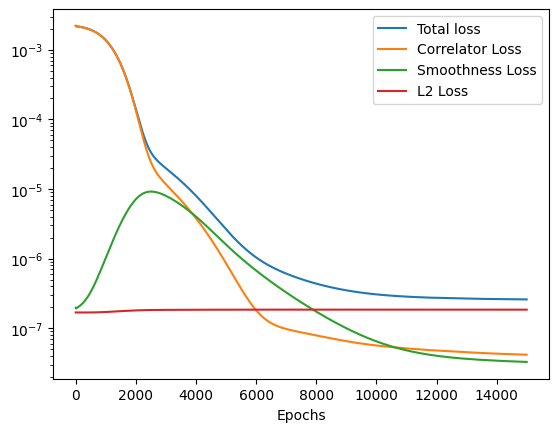

In [12]:
trainingepochs=range(new_epochs)

plt.figure()
plt.plot(trainingepochs,np.mean(total_loss_history_ensemble,axis=0),label=r'Total loss')
plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[0].T,axis=0),label=r'Correlator Loss')
plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[1].T,axis=0)*lambda_s,label=r'Smoothness Loss')
plt.plot(trainingepochs,np.mean(loss_history_ensemble.T[2].T,axis=0)*0.5*lambda_l2,label=r'L2 Loss')

plt.yscale('log')
plt.legend()
plt.xlabel('Epochs')

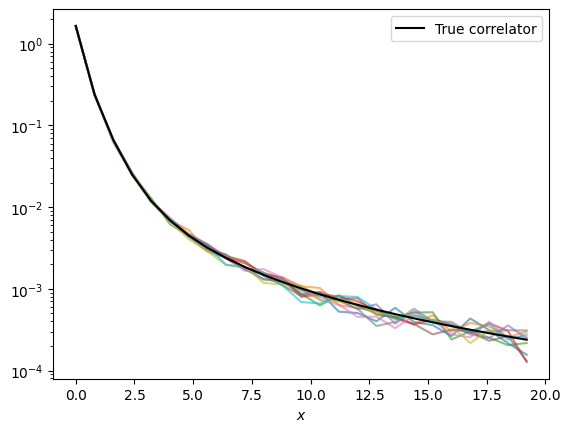

In [13]:

# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
for i in range(len(noisy_Dxi_ensemble)):
    plt.plot(x, noisy_Dxi_ensemble[i], alpha=0.6)
plt.plot(x,Dxi_ensemble[0], label=r'True correlator',color='black')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.legend()
plt.show()

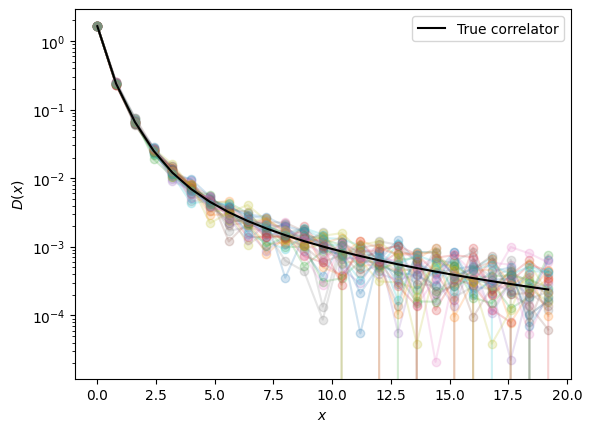

In [83]:

# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
for i in range(len(noisy_Dxi_ensemble)):
    plt.plot(x, noisy_Dxi_ensemble[i], alpha=0.2,ls='-',marker='o')
plt.plot(x,Dxi_ensemble[0], label=r'True correlator',color='black')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.ylabel(r'$D(x)$')
plt.legend()
plt.show()

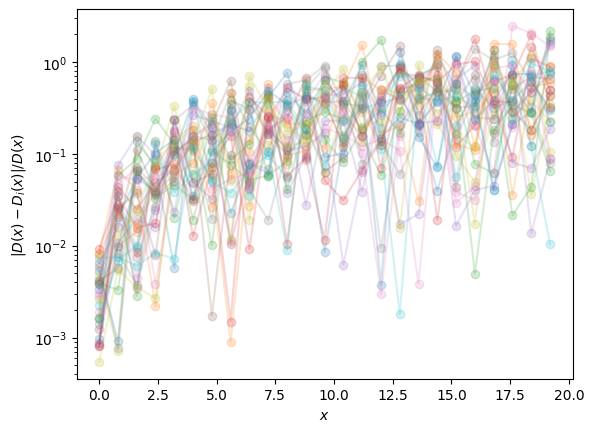

In [87]:
# relative deviation
for i in range(len(noisy_Dxi_ensemble)):
    plt.plot(x, np.abs(noisy_Dxi_ensemble[i]-Dxi_ensemble[0])/Dxi_ensemble[0], alpha=0.2,ls='-',marker='o')
# plt.plot(x,Dxi_ensemble[0], label=r'True correlator',color='black')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.ylabel(r'$|D(x)-D_i(x)|/D(x)$')
# plt.legend()
plt.show()

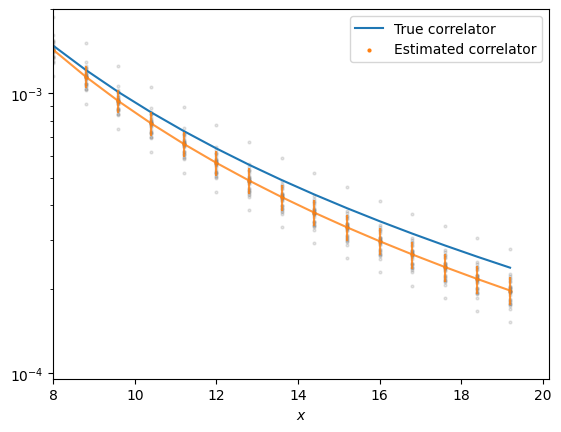

In [11]:
plt.plot(x,Dxi_ensemble[0], label=r'True correlator')
# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
import correlator
correlatorPredictions=[]
for i in range(num_samples):
    rho=rho_ensemble[i]
    klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
    Dxi_prediction=correlator.Di(klW_ker_Pos,rho,del_omega)
    correlatorPredictions.append(Dxi_prediction)
correlatorPredictions=np.array(correlatorPredictions)
meanDxi=bootstrapMean(correlatorPredictions)
varDxi=bootstrapVariance(correlatorPredictions)
plt.errorbar(x,meanDxi,yerr=np.sqrt(varDxi),alpha=0.8,color='C1')
plt.scatter(x,meanDxi, label=r'Estimated correlator',color='C1',s=4)
for i in range(num_samples):
    plt.scatter(x, correlatorPredictions[i], alpha=0.2, s=4,color='gray')
plt.yscale('log')
plt.xlabel(r'$x$')
plt.xlim(8,None)
plt.ylim(None,2e-3)
plt.legend()
plt.show()

# Multifit vs Bootstrapped Single Fit

In [50]:
rho_ensemble=np.load('data/rho_Ensemble_30_corrs.npy')
loss_history_ensemble=np.load('data/loss_history_Ensemble_30_corrs.npy')
total_loss_history_ensemble=np.load('data/total_loss_history_Ensemble_30_corrs.npy')

rho_ensemble_NN=np.load('data/rho_Ensemble_30_corrs_NN.npy')
loss_history_ensemble_NN=np.load('data/loss_history_Ensemble_30_corrs_NN.npy')
total_loss_history_ensemble_NN=np.load('data/total_loss_history_Ensemble_30_corrs_NN.npy')

rho_multifit=np.load('data/rho_Multifit_30_corrs.npy')
loss_history_multifit=np.load('data/loss_history_Multifit_30_corrs.npy')
total_loss_history_multifit=np.load('data/total_loss_history_Multifit_30_corrs.npy')

rho_multifit_NN=np.load('data/rho_Multifit_30_corrs_NN.npy')
loss_history_multifit_NN=np.load('data/loss_history_Multifit_30_corrs_NN.npy')
total_loss_history_multifit_NN=np.load('data/total_loss_history_Multifit_30_corrs_NN.npy')

rho_ensemble_rhoFit=np.load('data/rho_Ensemble_30_corrs_rhoFit.npy')
loss_history_ensemble_rhoFit=np.load('data/loss_history_Ensemble_30_corrs_rhoFit.npy')
total_loss_history_ensemble_rhoFit=np.load('data/total_loss_history_Ensemble_30_corrs_rhoFit.npy')

rho_multifit_rhoFit=np.load('data/rho_Multifit_30_corrs_rhoFit.npy')
loss_history_multifit_rhoFit=np.load('data/loss_history_Multifit_30_corrs_rhoFit.npy')
total_loss_history_multifit_rhoFit=np.load('data/total_loss_history_Multifit_30_corrs_rhoFit.npy')
num_samples=30

In [51]:
def bootstrapMean(samples):
    mean=np.mean(samples,axis=0)
    mean=np.squeeze(mean)
    return mean

def bootstrapVariance(samples):
    mean=bootstrapMean(samples)
    variance=np.mean((samples-mean)**2,axis=0)
    return variance

Text(0, 0.5, '$\\rho/\\omega$')

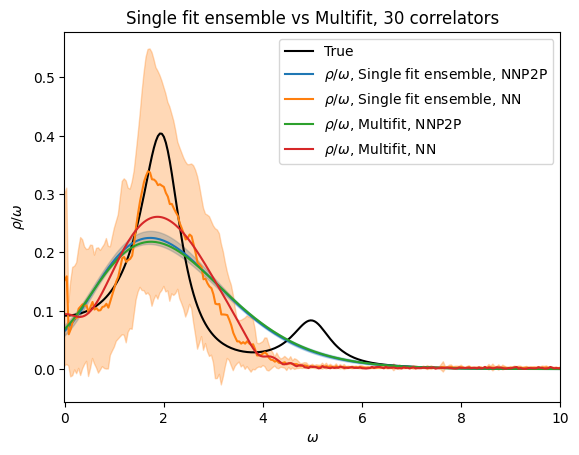

In [68]:
mean=bootstrapMean(np.squeeze(np.array(rho_ensemble)))
variance=bootstrapVariance(np.squeeze(np.array(rho_ensemble)))
mean_NN=bootstrapMean(np.squeeze(np.array(rho_ensemble_NN)))
variance_NN=bootstrapVariance(np.squeeze(np.array(rho_ensemble_NN)))

fig=plt.figure()
ax=plt.gca()

plt.plot(omega,spec2BWOverOmega, label=r'True',color='black')

color="C0"
plt.plot(omega,mean, label=r'$\rho/\omega$, Single fit ensemble, NNP2P',color=color)
# plt.errorbar(omega,mean,yerr=np.sqrt(variance),alpha=0.7,color=color,elinewidth=2)
plt.fill_between(omega, mean-np.sqrt(variance), mean+np.sqrt(variance),color=color,alpha=0.3)

color="C1"
plt.plot(omega,mean_NN, label=r'$\rho/\omega$, Single fit ensemble, NN',color=color)
# plt.errorbar(omega,mean_NN,yerr=np.sqrt(variance_NN),alpha=0.7,color=color,elinewidth=2)
plt.fill_between(omega, mean_NN-np.sqrt(variance_NN), mean_NN+np.sqrt(variance_NN),color=color,alpha=0.3)


color="C2"
plt.plot(omega,rho_multifit, label=r'$\rho/\omega$, Multifit, NNP2P',color=color)

color="C3"
plt.plot(omega,np.squeeze(rho_multifit_NN), label=r'$\rho/\omega$, Multifit, NN',color=color)

plt.legend()
plt.title('Single fit ensemble vs Multifit, 30 correlators')
plt.xlim(-0.01,10)
# plt.ylim(None,0.4)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


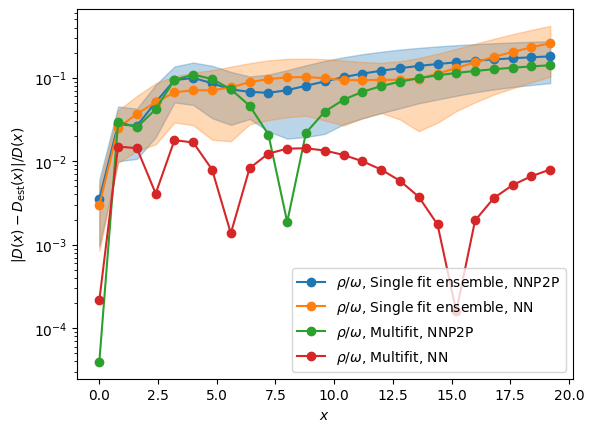

In [56]:
import correlator
kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
Dxi = correlator.Di(kl_ker_Pos,spec2BW,del_omega)
correlatorPredictions=[]
for i in range(num_samples):
    rho=rho_ensemble[i]
    Dxi_prediction=correlator.Di(klW_ker_Pos,rho,del_omega)
    correlatorPredictions.append(Dxi_prediction)
correlatorPredictions=np.array(correlatorPredictions)

relativeSamples=np.abs(correlatorPredictions-Dxi)/Dxi
meanrelative=bootstrapMean(relativeSamples)
varrelative=bootstrapVariance(relativeSamples)

correlatorPredictions_NN=[]
for i in range(num_samples):
    rho=rho_ensemble_NN[i]
    Dxi_prediction=correlator.Di(klW_ker_Pos,rho,del_omega)
    correlatorPredictions_NN.append(Dxi_prediction)
correlatorPredictions_NN=np.array(correlatorPredictions_NN)

relativeSamples_NN=np.abs(correlatorPredictions_NN-Dxi)/Dxi
meanrelative_NN=bootstrapMean(relativeSamples_NN)
varrelative_NN=bootstrapVariance(relativeSamples_NN)

fig=plt.figure()
ax=plt.gca()


color="C0"
plt.plot(x,meanrelative, label=r'$\rho/\omega$, Single fit ensemble, NNP2P',color=color,marker='o')
# plt.errorbar(omega,mean,yerr=np.sqrt(variance),alpha=0.7,color=color,elinewidth=2)
plt.fill_between(x, meanrelative-np.sqrt(varrelative), meanrelative+np.sqrt(varrelative),color=color,alpha=0.3)

color="C1"
plt.plot(x,meanrelative_NN, label=r'$\rho/\omega$, Single fit ensemble, NN',color=color,marker='o')
# plt.errorbar(omega,mean_NN,yerr=np.sqrt(variance_NN),alpha=0.7,color=color,elinewidth=2)
plt.fill_between(x, meanrelative_NN-np.sqrt(varrelative_NN), meanrelative_NN+np.sqrt(varrelative_NN),color=color,alpha=0.3)


color="C2"
Dxi_multifit=correlator.Di(klW_ker_Pos,rho_multifit,del_omega)

plt.plot(x,np.abs(Dxi_multifit-Dxi)/Dxi, label=r'$\rho/\omega$, Multifit, NNP2P',color=color,marker='o')

color="C3"
Dxi_multifit_NN=correlator.Di(klW_ker_Pos,rho_multifit_NN,del_omega)
plt.plot(x,np.abs(Dxi_multifit_NN-Dxi)/Dxi, label=r'$\rho/\omega$, Multifit, NN',color=color,marker='o')

plt.yscale('log')
plt.xlabel(r'$x$')
# plt.xlim(8,None)
# plt.ylim(None,2e-3)
plt.legend()
plt.xlabel(r'$x$')
plt.ylabel(r'$|D(x)-D_{\mathrm{est}}(x)|/D(x)$')
plt.show()

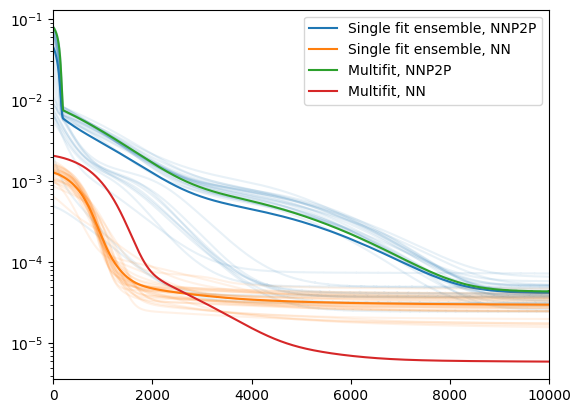

In [67]:
total_loss_histories=[np.mean(total_loss_history_ensemble,axis=0),np.mean(total_loss_history_ensemble_NN,axis=0),total_loss_history_multifit,total_loss_history_multifit_NN]

fig=plt.figure()
ax=plt.gca()

color="C0"
plt.plot(total_loss_histories[0], label=r'Single fit ensemble, NNP2P',color=color)
for i in range(num_samples):
    plt.plot(total_loss_history_ensemble[i], alpha=0.1,color=color)

color="C1"
plt.plot(total_loss_histories[1], label=r'Single fit ensemble, NN',color=color)
for i in range(num_samples):
    plt.plot(total_loss_history_ensemble_NN[i], alpha=0.1,color=color)

color="C2"
plt.plot(total_loss_histories[2], label=r'Multifit, NNP2P',color=color)

color="C3"
plt.plot(total_loss_histories[3], label=r'Multifit, NN',color=color)

plt.xlim(0,10000)
plt.yscale('log')
plt.legend()

/tmp/ipykernel_675116/2364015757.py:3: RuntimeWarning: divide by zero encountered in divide
  mean_rhoFit=bootstrapMean(np.squeeze(np.array(rho_ensemble_rhoFit))/omega)
/tmp/ipykernel_675116/2364015757.py:4: RuntimeWarning: divide by zero encountered in divide
  variance_rhoFit=bootstrapVariance(np.squeeze(np.array(rho_ensemble_rhoFit))/omega)
/tmp/ipykernel_675116/3188300730.py:8: RuntimeWarning: invalid value encountered in subtract
  variance=np.mean((samples-mean)**2,axis=0)
/tmp/ipykernel_675116/2364015757.py:26: RuntimeWarning: divide by zero encountered in divide
  plt.plot(omega,np.squeeze(rho_multifit_rhoFit)/(omega), label=r'$\rho$, Multifit, NNP2P',color=color)


Text(0, 0.5, '$\\rho/\\omega$')

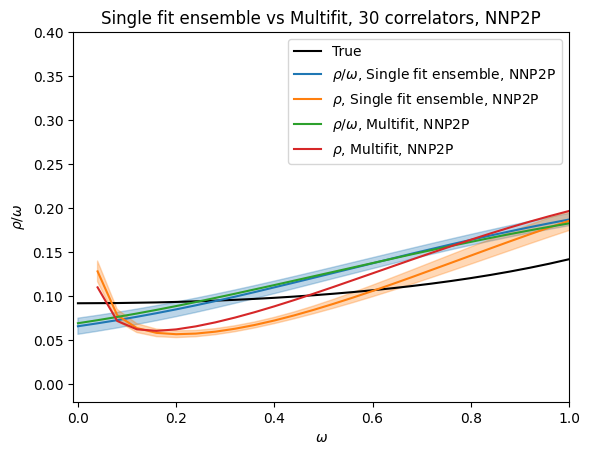

In [17]:
mean=bootstrapMean(np.squeeze(np.array(rho_ensemble)))
variance=bootstrapVariance(np.squeeze(np.array(rho_ensemble)))
mean_rhoFit=bootstrapMean(np.squeeze(np.array(rho_ensemble_rhoFit))/omega)
variance_rhoFit=bootstrapVariance(np.squeeze(np.array(rho_ensemble_rhoFit))/omega)

fig=plt.figure()
ax=plt.gca()

plt.plot(omega,spec2BWOverOmega, label=r'True',color='black')

color="C0"
plt.plot(omega,mean, label=r'$\rho/\omega$, Single fit ensemble, NNP2P',color=color)
# plt.errorbar(omega,mean,yerr=np.sqrt(variance),alpha=0.7,color=color,elinewidth=2)
plt.fill_between(omega, mean-np.sqrt(variance), mean+np.sqrt(variance),color=color,alpha=0.3)

color="C1"
plt.plot(omega,mean_rhoFit, label=r'$\rho$, Single fit ensemble, NNP2P',color=color)
# plt.errorbar(omega,mean_NN,yerr=np.sqrt(variance_NN),alpha=0.7,color=color,elinewidth=2)
plt.fill_between(omega, mean_rhoFit-np.sqrt(variance_rhoFit), mean_rhoFit+np.sqrt(variance_rhoFit),color=color,alpha=0.3)


color="C2"
plt.plot(omega,rho_multifit, label=r'$\rho/\omega$, Multifit, NNP2P',color=color)

color="C3"
plt.plot(omega,np.squeeze(rho_multifit_rhoFit)/(omega), label=r'$\rho$, Multifit, NNP2P',color=color)

plt.legend()
plt.title('Single fit ensemble vs Multifit, 30 correlators, NNP2P')
plt.xlim(-0.01,1)
plt.ylim(None,0.4)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')


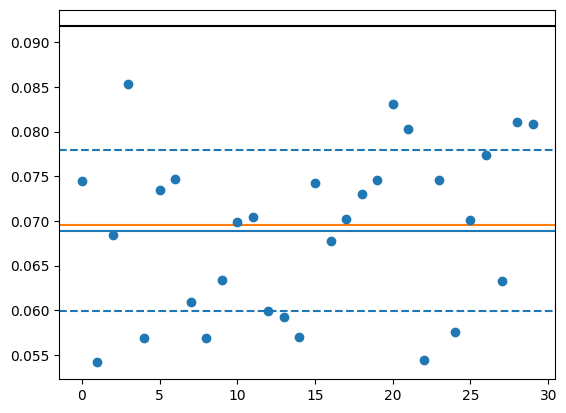

In [121]:
plt.axhline(spec2BW[1]/omega[1],color='black',ls='-')
# plt.axhline(rho_multifit[0],label='Multifit',color='C1')
plt.axhline(rho_multifit[1],color='C1')

plt.plot(rho_ensemble.T[0][1],label='Single fit ensemble',color='C0',marker='o',ls='None')
plt.axhline(mean[1],color='C0')
plt.axhline(mean[1]+np.sqrt(variance[1]),color='C0',ls='--')
plt.axhline(mean[1]-np.sqrt(variance[1]),color='C0',ls='--')



In [18]:
# Training compared to Multifit

trainingepochs=range(new_epochs)

total_loss_var=bootstrapMean(total_loss_history_ensemble)
plt.plot(trainingepochs,np.mean(total_loss_history_ensemble,axis=0),label=r'$\rho/\omega$, Single fit',color='C0')
plt.errorbar(trainingepochs,np.mean(total_loss_history_ensemble,axis=0),yerr=np.sqrt(bootstrapVariance(total_loss_history_ensemble)),alpha=0.01,color='C0')
plt.plot(np.mean(total_loss_history_ensemble_rhoFit,axis=0),label=r'$\rho/\omega$, Single fit',color='C1')
plt.errorbar(trainingepochs,np.mean(total_loss_history_ensemble_rhoFit,axis=0),yerr=np.sqrt(bootstrapVariance(total_loss_history_ensemble_rhoFit)),alpha=0.01,color='C1')


plt.plot(total_loss_history_multifit,label=r'$\rho/\omega$, Multifit',color='C2')
plt.plot(total_loss_history_multifit_rhoFit,label=r'$\rho$, Multifit',color='C3')

plt.ylabel('Total loss')
plt.xlabel('Epochs')
plt.yscale('log')
plt.legend()


NameError: name 'new_epochs' is not defined

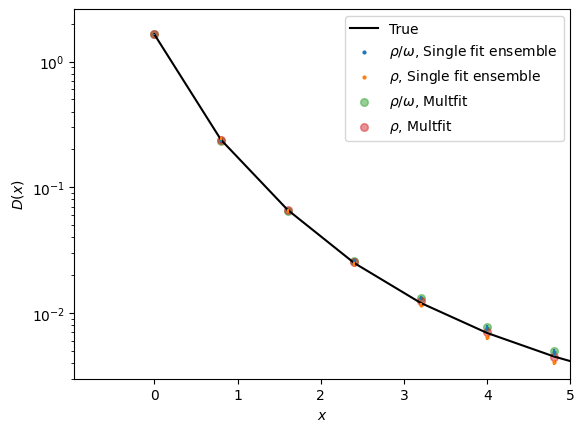

In [80]:
# compare the correlators

plt.plot(x,Dxi_ensemble[0], label=r'True',color='black')
# plt.plot(x,noisy_Dxi_ensemble.T, label=r'Noisy correlator')
import correlator
correlatorPredictions=[]
for i in range(num_samples):
    rho=rho_ensemble[i]
    klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
    Dxi_prediction=correlator.Di(klW_ker_Pos,rho,del_omega)
    correlatorPredictions.append(Dxi_prediction)
correlatorPredictions=np.array(correlatorPredictions)
meanDxi=bootstrapMean(correlatorPredictions)
varDxi=bootstrapVariance(correlatorPredictions)
plt.errorbar(x,meanDxi,yerr=np.sqrt(varDxi),alpha=1.0,color='C0',ls='None')
plt.scatter(x,meanDxi, label=r'$\rho/\omega$, Single fit ensemble',color='C0',s=4)
# for i in range(num_samples):
#     plt.scatter(x, correlatorPredictions[i], alpha=0.2, s=4,color='gray')

correlatorPredictions_rhoFit=[]
for i in range(num_samples):
    rho=rho_ensemble_rhoFit[i]
    kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
    Dxi_prediction=correlator.Di(kl_ker_Pos,rho,del_omega)
    correlatorPredictions_rhoFit.append(Dxi_prediction)
correlatorPredictions_rhoFit=np.array(correlatorPredictions_rhoFit)
meanDxi=bootstrapMean(correlatorPredictions_rhoFit)
varDxi=bootstrapVariance(correlatorPredictions_rhoFit)
plt.errorbar(x,meanDxi,yerr=np.sqrt(varDxi),alpha=1.0,color='C1',ls='None')
plt.scatter(x,meanDxi, label=r'$\rho$, Single fit ensemble',color='C1',s=4)


Dxi_multifit=correlator.Di(klW_ker_Pos,rho_multifit,del_omega)
plt.scatter(x,Dxi_multifit, label=r'$\rho/\omega$, Multfit',color='C2',alpha=0.5,s=30)
Dxi_multifit_rhoFit=correlator.Di(kl_ker_Pos,rho_multifit_rhoFit,del_omega)
plt.scatter(x,Dxi_multifit_rhoFit, label=r'$\rho$, Multfit',color='C3',alpha=0.5,s=30)

plt.yscale('log')
plt.xlabel(r'$x$')
# plt.xlim(8,None)
# plt.ylim(None,2e-3)
plt.xlim(None,5)
plt.ylim(3e-3,None)
plt.legend()
plt.xlabel(r'$x$')
plt.ylabel(r'$D(x)$')
plt.show()

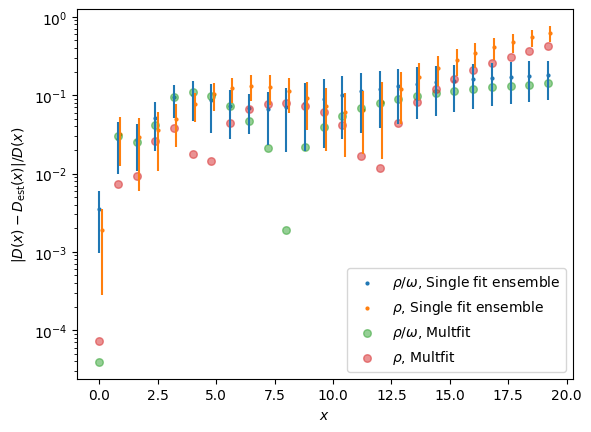

In [85]:
# compare the correlators

relativeSamples=np.abs(correlatorPredictions-Dxi_ensemble[0])/Dxi_ensemble[0]
meanrelative=bootstrapMean(relativeSamples)
varrelative=bootstrapVariance(relativeSamples)

relativeSamples_rhoFit=np.abs(correlatorPredictions_rhoFit-Dxi_ensemble[0])/Dxi_ensemble[0]
meanrelative_rhoFit=bootstrapMean(relativeSamples_rhoFit)
varrelative_rhoFit=bootstrapVariance(relativeSamples_rhoFit)




plt.errorbar(x,meanrelative,yerr=np.sqrt(varrelative),alpha=1.0,color='C0',ls='None')
plt.scatter(x,meanrelative, label=r'$\rho/\omega$, Single fit ensemble',color='C0',s=4)

plt.errorbar(x+0.1,meanrelative_rhoFit,yerr=np.sqrt(varrelative_rhoFit),alpha=1.0,color='C1',ls='None')
plt.scatter(x+0.1,meanrelative_rhoFit, label=r'$\rho$, Single fit ensemble',color='C1',s=4)


Dxi_multifit=correlator.Di(klW_ker_Pos,rho_multifit,del_omega)
plt.scatter(x,np.abs(Dxi_multifit-Dxi_ensemble[0])/Dxi_ensemble[0], label=r'$\rho/\omega$, Multfit',color='C2',alpha=0.5,s=30)

Dxi_multifit_rhoFit=correlator.Di(kl_ker_Pos,rho_multifit_rhoFit,del_omega)
plt.scatter(x,np.abs(Dxi_multifit_rhoFit-Dxi_ensemble[0])/Dxi_ensemble[0], label=r'$\rho$, Multfit',color='C3',alpha=0.5,s=30)

plt.yscale('log')
plt.xlabel(r'$x$')
# plt.xlim(8,None)
# plt.ylim(None,2e-3)
plt.legend()
plt.xlabel(r'$x$')
plt.ylabel(r'$|D(x)-D_{\mathrm{est}}(x)|/D(x)$')
plt.show()